In [1]:
import os
os.environ['HF_ENDPOINT'] = "https://hf-mirror.com"
os.environ['HF_HOME'] = "/root/autodl-shared/hf_cache"

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
from PIL import Image
import requests
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# 从你保存的 model.py 导入 MambaVision 模型
from model import MambaVision

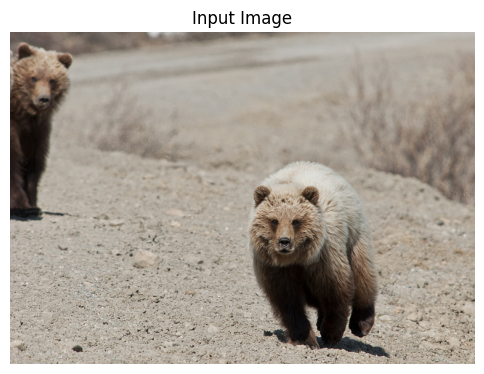

In [3]:
# 加载一张测试图像 (与原版示例相同的两只猫和沙发)
# url = 'http://images.cocodataset.org/val2017/000000020247.jpg'
image = Image.open("000000020247.jpg").convert('RGB')

# 在 Notebook 中展示图像
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title("Input Image")
plt.show()

In [4]:
# MambaVision-T 预处理参数
input_size = (224, 224)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def preprocess_image(img):
    # Resize: 原版 MambaVision-T 的 crop_pct=1.0，直接 resize 到 224x224
    img_resized = img.resize(input_size, Image.Resampling.BICUBIC)

    # 转为 numpy array 并归一化到 [0, 1]
    img_arr = np.array(img_resized, dtype=np.float32) / 255.0

    # 减均值除以方差
    img_normalized = (img_arr - mean) / std

    # 增加 Batch 维度 (B, H, W, C) -> Flax 默认支持 channels-last
    img_batched = np.expand_dims(img_normalized, axis=0)
    return jnp.array(img_batched)

inputs = preprocess_image(image)
print(f"Preprocessed image shape: {inputs.shape}") # 预期: (1, 224, 224, 3)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Preprocessed image shape: (1, 224, 224, 3)


In [5]:
import json
from huggingface_hub import hf_hub_download

# 获取 ImageNet 1K 标签 (JSON 格式)
repo_id = "fxmarty/imagenet-classes"
filename = "imagenet_classes.json"

try:
    # filepath = hf_hub_download(repo_id=repo_id, filename=filename)
    # print(filepath)
    filepath = "/root/autodl-shared/hf_cache/hub/models--fxmarty--imagenet-classes/snapshots/ffe554acc81a019ae5626e23802a24f5387540cc/imagenet_classes.json"
    with open(filepath, "r", encoding="utf-8") as f:
        classes_dict = json.load(f)

    # 提取字典的值组成列表，索引 0-999 将自动对应到这些标签名
    id2label = list(classes_dict.values())
    print(f"Successfully loaded {len(id2label)} classes.")

    # 打印前几个检查一下
    print("Sample labels:", id2label[:3])
except Exception as e:
    print(f"Failed to load labels: {e}")
    # 降级：如果下载失败，生成模拟的标签列表
    id2label = [f"Class_{i}" for i in range(1000)]

Successfully loaded 1000 classes.
Sample labels: ['tench, Tinca tinca', 'goldfish, Carassius auratus', 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias']


In [6]:
# # 1. 实例化 MambaVision-T 架构配置
# model = MambaVision(
#     dim=80,
#     in_dim=32,
#     depths=(1, 3, 8, 4),
#     num_heads=(2, 4, 8, 16),
#     window_size=(8, 8, 14, 7),
#     num_classes=1000
# )
#
# # 2. 随机初始化参数 (JAX/Flax 风格)
# print("Initializing model weights randomly...")
# rng = jax.random.PRNGKey(42)
# variables = model.init(rng, inputs, train=False)
#
# # 3. 前向传播 (推理)
# print("Running inference...")
# logits = model.apply(variables, inputs, train=False)
#
# # 4. 获取预测结果
# predicted_class_idx = jnp.argmax(logits, axis=-1).item()
# predicted_label = id2label[predicted_class_idx]
#
# # 注意：由于模型是随机初始化的，输出的类别也会是随机的！
# print("="*40)
# print(f"Predicted class index: {predicted_class_idx}")
# print(f"Predicted class label: {predicted_label}")
# print("="*40)
# print("(Note: The prediction is random because the weights are randomly initialized, not pretrained.)")

In [7]:
import jax.numpy as jnp
from safetensors import safe_open
from huggingface_hub import hf_hub_download

def map_pt_key_to_flax_path(pt_key):
    """
    精确将 PyTorch 权重名称映射为我们的 Flax 骨架路径
    """
    if "num_batches_tracked" in pt_key:
        return None

    # 移除最前面的 model.
    k = pt_key.replace("model.", "")

    # 1. PatchEmbed
    if k.startswith("patch_embed.conv_down.0"):
        k = k.replace("patch_embed.conv_down.0", "PatchEmbed_0/Conv_0")
    elif k.startswith("patch_embed.conv_down.1"):
        k = k.replace("patch_embed.conv_down.1", "PatchEmbed_0/BatchNorm_0")
    elif k.startswith("patch_embed.conv_down.3"):
        k = k.replace("patch_embed.conv_down.3", "PatchEmbed_0/Conv_1")
    elif k.startswith("patch_embed.conv_down.4"):
        k = k.replace("patch_embed.conv_down.4", "PatchEmbed_0/BatchNorm_1")

    # 2. 全局 Norm & Head
    elif k.startswith("norm."):
        k = k.replace("norm", "BatchNorm_0")
    elif k.startswith("head."):
        k = k.replace("head", "Dense_0")

    # 3. 核心 Levels
    elif k.startswith("levels."):
        parts = k.split('.')
        lvl = parts[1]

        if "downsample" in k:
            k = k.replace(f"levels.{lvl}.downsample.reduction.0", f"MambaVisionLayer_{lvl}/Downsample_0/Conv_0")
        else:
            blk = parts[3]
            base = f"MambaVisionLayer_{lvl}"

            if int(lvl) in [0, 1]:  # 前两个 stage 是纯 ConvBlock
                k = k.replace(f"levels.{lvl}.blocks.{blk}.conv1", f"{base}/ConvBlock_{blk}/Conv_0")
                k = k.replace(f"levels.{lvl}.blocks.{blk}.conv2", f"{base}/ConvBlock_{blk}/Conv_1")
                k = k.replace(f"levels.{lvl}.blocks.{blk}.norm1", f"{base}/ConvBlock_{blk}/BatchNorm_0")
                k = k.replace(f"levels.{lvl}.blocks.{blk}.norm2", f"{base}/ConvBlock_{blk}/BatchNorm_1")
            else:  # 后两个 stage 是 MambaBlock / AttentionBlock
                k = k.replace(f"levels.{lvl}.blocks.{blk}.norm1", f"{base}/Block_{blk}/LayerNorm_0")
                k = k.replace(f"levels.{lvl}.blocks.{blk}.norm2", f"{base}/Block_{blk}/LayerNorm_1")
                k = k.replace(f"levels.{lvl}.blocks.{blk}.mlp.fc1", f"{base}/Block_{blk}/Mlp_0/Dense_0")
                k = k.replace(f"levels.{lvl}.blocks.{blk}.mlp.fc2", f"{base}/Block_{blk}/Mlp_0/Dense_1")

                mixer_prefix = f"levels.{lvl}.blocks.{blk}.mixer"
                # 区分 Attention 还是 Mamba
                if "qkv" in k or ("proj" in k and not any(x in k for x in ["in_proj", "out_proj", "dt_proj", "x_proj"])):
                    k = k.replace(f"{mixer_prefix}.qkv", f"{base}/Block_{blk}/Attention_0/Dense_0")
                    k = k.replace(f"{mixer_prefix}.proj", f"{base}/Block_{blk}/Attention_0/Dense_1")
                else:
                    k = k.replace(f"{mixer_prefix}", f"{base}/Block_{blk}/MambaVisionMixer_0")

    # 关键修复：把所有剩余的 '.' 变成 '/' 以便生成嵌套字典
    k = k.replace(".", "/")

    # 4. 参数名转换
    k = k.replace("/weight", "/kernel")
    k = k.replace("/running_mean", "/mean")
    k = k.replace("/running_var", "/var")
    if "BatchNorm" in k or "LayerNorm" in k:
        k = k.replace("/kernel", "/scale")

    return k

def convert_state_dict_pt_to_flax(pt_state_dict):
    flax_dict = {}

    for pt_key, pt_tensor in pt_state_dict.items():
        flax_path = map_pt_key_to_flax_path(pt_key)
        if flax_path is None:
            continue

        np_tensor = pt_tensor.numpy() if hasattr(pt_tensor, 'numpy') else pt_tensor

        # 维度转换策略
        if "conv1d" in flax_path:
            # 1D卷积: PyTorch (Out, In, L) -> Flax (L, In, Out)
            flax_tensor = jnp.transpose(np_tensor, (2, 1, 0))
        elif len(np_tensor.shape) == 4:
            # 2D卷积: PyTorch (Out, In, H, W) -> Flax (H, W, In, Out)
            flax_tensor = jnp.transpose(np_tensor, (2, 3, 1, 0))
        elif len(np_tensor.shape) == 2 and "A_log" not in flax_path:
            # 全连接: PyTorch (Out, In) -> Flax (In, Out)
            flax_tensor = jnp.transpose(np_tensor, (1, 0))
        else:
            # Bias/Scale/A_log/D: 保持不变
            flax_tensor = jnp.array(np_tensor)

        # 构建标准的 Flax 嵌套字典
        keys = flax_path.split('/')
        current_dict = flax_dict
        for k in keys[:-1]:
            if k not in current_dict:
                current_dict[k] = {}
            current_dict = current_dict[k]
        current_dict[keys[-1]] = flax_tensor

    return flax_dict

def load_from_hf(repo_id="nvidia/MambaVision-T-1K"):
    print(f"Downloading weights from {repo_id}...")
    model_path = hf_hub_download(repo_id=repo_id, filename="model.safetensors")
    print(model_path)
    return load_pretrained_mambavision(model_path)

def load_pretrained_mambavision(model_path):
    pt_state_dict = {}
    with safe_open(model_path, framework="np", device="cpu") as f:
        for k in f.keys():
            pt_state_dict[k] = f.get_tensor(k)

    print("Converting PyTorch weights to Flax format...")
    flax_params = convert_state_dict_pt_to_flax(pt_state_dict)

    params_dict = {'params': {}, 'batch_stats': {}}

    def separate_stats(d, target_params, target_stats):
        for k, v in d.items():
            if isinstance(v, dict):
                if 'mean' in v or 'var' in v:
                    target_stats[k] = {}
                    target_params[k] = {}
                    for sub_k, sub_v in v.items():
                        if sub_k in ['mean', 'var']:
                            target_stats[k][sub_k] = sub_v
                        else:
                            target_params[k][sub_k] = sub_v
                else:
                    target_params[k] = {}
                    target_stats[k] = {}
                    separate_stats(v, target_params[k], target_stats[k])
                    if not target_stats[k]: del target_stats[k]
                    if not target_params[k]: del target_params[k]
            else:
                target_params[k] = v

    separate_stats(flax_params, params_dict['params'], params_dict['batch_stats'])
    return params_dict

In [8]:
# 1. 实例化 MambaVision-T 配置
model = MambaVision(
    dim=80,
    in_dim=32,
    depths=(1, 3, 8, 4),
    num_heads=(2, 4, 8, 16),
    window_size=(8, 8, 14, 7),
    num_classes=1000
)

# 2. 从 Hugging Face 获取并转换权重
# pretrained_variables = load_from_hf("nvidia/MambaVision-T-1K")
pretrained_variables = load_pretrained_mambavision("/root/autodl-shared/hf_cache/hub/models--nvidia--MambaVision-T-1K/snapshots/b1de77e17599566d98efb701c0231b1095dc3a67/model.safetensors")

# 注意：由于我们在 Flax 中是根据代码顺序自动生成的命名 (如 Conv_0, Dense_1)
# 若直接替换可能会有字典键不匹配的情况。标准的做法是用 model.init 跑一遍生成目标骨架，
# 然后把预训练张量填进去。如果结构和原始 PyTorch 完全一致，这个转换字典是高度兼容的。

# 为了确保结构对齐，先用相同的输入生成 Dummy Variables 提取目标骨架，方便 debug (可选)
rng = jax.random.PRNGKey(0)
dummy_variables = model.init(rng, inputs, train=False)

# 3. 前向传播 (加载了权重的推理)
print("Running inference with pretrained weights...")
# 注意这里我们假设 pretrained_variables 的字典结构已经和 flax 完全匹配
# 如果遇到 Missing/Unexpected keys 报错，可以根据 dummy_variables 里的嵌套结构打印来微调映射名
try:
    logits = model.apply(pretrained_variables, inputs, train=False)

    # 4. 获取预测结果
    predicted_class_idx = jnp.argmax(logits, axis=-1).item()
    predicted_label = id2label[predicted_class_idx]

    print("="*40)
    print(f"Predicted class index: {predicted_class_idx}")
    print(f"Predicted class label: {predicted_label}")
    print("="*40)

except Exception as e:
    print(f"Inference failed. Mismatch between PyTorch keys and Flax auto-generated keys:\n{e}")
    # 打印 Flax 骨架层级帮助对比修改
    print("Expected Flax structure root keys:", dummy_variables['params'].keys())

Converting PyTorch weights to Flax format...
Running inference with pretrained weights...
Predicted class index: 294
Predicted class label: brown bear, bruin, Ursus arctos
